# Modèle final pour `/recommend`

| | |
|---|---|
| **Objectif** | comparer en situation de recommandation les trois finalistes du notebook 14 (ExtraTrees, CatBoost, LightGBM), choisir le modèle final, l'évaluer sur 2013 et le sauvegarder pour l'API |
| **Entrées** | `data/processed/recommend_training_dataset.csv` (notebook 06) ; coordonnées des pays tirées de `data/geo/ne_110m_admin_0_countries.geojson` ; réglages des finalistes (`RECOMMEND_FINALISTS`) |
| **Sorties** | `models/recommend_model.joblib` (pipeline complet) et `models/recommend_model_metadata.json` ; run MLflow `extra_trees_history_final_test` |
| **Cible** | `yield_t_ha`, rendement en t/ha ; métriques : RMSE, MAE, R² |
| **Protocole** | choix sur la validation temporelle 2008-2012, sur les lignes qui ont un historique (1991-2012) ; 2013 utilisée une seule fois, après le choix, pour le seul modèle retenu |
| **Features** | représentation `history` : `crop`, `year`, `temp_hist`, `rain_mm`, `log_pest_hist`, `lat_abs`, `geo_x`, `geo_y`, `geo_z` |

**2013 n'a servi à aucun choix.**

## Imports

In [1]:
import json
import platform
import tempfile
import time
from datetime import date
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.base import clone
from sklearn.ensemble import ExtraTreesRegressor

from agritech.config import PATHS, SEED
from agritech.evaluation import errors_by_crop, regression_metrics
from agritech.forest_size import (
    STRUCTURELS,
    deployable,
    foret,
    lancer,
    mesurer_artefact,
    normaliser,
    pareto,
    preparer_matrices,
    reglages_depuis,
    scores_par_prefixe,
    structure,
    taille,
    tronquer,
    voisins,
)
from agritech.geo import charger_coordonnees, plot_carte_categories
from agritech.interpretation import permutation_importance_by_family
from agritech.modeling import RunInfo, experiment_pipeline, log_model_run, run_experiment
from agritech.preprocessing import PREPROCESSING_DESCRIPTION
from agritech.recommend_config import (
    RECOMMEND_COLUMNS,
    RECOMMEND_CROPS,
    RECOMMEND_DATASET,
    RECOMMEND_FINALISTS,
    RECOMMEND_GEOGRAPHY,
    RECOMMEND_HISTORICAL_CONDITIONS,
    RECOMMEND_ROWS,
    RECOMMEND_TARGET,
    RECOMMEND_TEST_YEAR,
    RECOMMEND_VALIDATION_YEARS,
)
from agritech.recommend_features import add_historical_conditions, add_recommend_features
from agritech.recommend_service import couples_observes, preparer_demande, recommander
from agritech.tracking import run_tags, setup_mlflow
from agritech.training_data import load_dataset, temporal_cv, temporal_protocol_params, temporal_split

# Données et protocole

Mêmes données et même protocole que le notebook 14 : représentation `history` (conditions moyennes des 3 années
précédentes, pluie du pays, géographie, année, culture), validation temporelle 2008-2012 sur les lignes qui ont un
historique. Ce sont les seules lignes apprises : elles vont de 1991 à 2012, 1990 servant seulement à calculer
l'historique de 1991. **2013 est retirée dès le découpage** : le dataset complet n'est relu que pour l'évaluation
finale.

In [2]:
df = load_dataset(RECOMMEND_DATASET, RECOMMEND_ROWS, RECOMMEND_COLUMNS, non_negative=[RECOMMEND_TARGET])
coordonnees = charger_coordonnees()
df = add_historical_conditions(add_recommend_features(df, coordonnees))

VARIABLES = ["iso3", "crop", "year", *RECOMMEND_HISTORICAL_CONDITIONS, *RECOMMEND_GEOGRAPHY]
X_train, X_test, y_train, y_test = temporal_split(df, VARIABLES, RECOMMEND_TARGET, RECOMMEND_TEST_YEAR)
CATEGORIELLES, NUMERIQUES = ["crop"], ["year", *RECOMMEND_HISTORICAL_CONDITIONS, *RECOMMEND_GEOGRAPHY]
avec_historique = X_train["temp_hist"].notna().to_numpy()
X_hist, y_hist = X_train[avec_historique], y_train[avec_historique]
# protocole des lignes réellement apprises, 1991-2012 : 1990 sert seulement à calculer l'historique de 1991
PARAMS_PROTOCOLE = temporal_protocol_params(
    RECOMMEND_DATASET, RECOMMEND_TARGET, X_hist, X_test, RECOMMEND_VALIDATION_YEARS, RECOMMEND_TEST_YEAR
)
# années connues de chaque pays, pour préparer une demande ; puis 2013 et le dataset complet sont oubliés
HISTORIQUE_PAYS = df.loc[df["year"] < RECOMMEND_TEST_YEAR, ["iso3", "year", "avg_temp", "rain_mm", "pesticides_t"]]
HISTORIQUE_PAYS = HISTORIQUE_PAYS.drop_duplicates(["iso3", "year"])
del df, X_test, y_test

ANNEES = RECOMMEND_VALIDATION_YEARS
print(f"\nlignes avec historique : {len(X_hist)} sur {len(X_train)} | variables : {CATEGORIELLES + NUMERIQUES}")
cv_hist = temporal_cv(X_hist["year"], ANNEES, RECOMMEND_TEST_YEAR)
assert X_hist["year"].max() < RECOMMEND_TEST_YEAR

fichier            : data/processed/recommend_training_dataset.csv
lignes x colonnes  : (16319, 8)
valeurs manquantes : 0
valeurs < 0        : 0 (yield_t_ha)
total   : 16319 lignes, 1990-2013
X_train : (15624, 10), 1990-2012
X_test  : (695, 10), 2013, réservé à l'évaluation finale
y_train : (15624,)
y_test  : (695,)

lignes avec historique : 14941 sur 15624 | variables : ['crop', 'year', 'temp_hist', 'rain_mm', 'log_pest_hist', 'lat_abs', 'geo_x', 'geo_y', 'geo_z']
validation 2008 : apprentissage 1991-2007 (11469 lignes) | 694 lignes évaluées
validation 2009 : apprentissage 1991-2008 (12163 lignes) | 692 lignes évaluées
validation 2010 : apprentissage 1991-2009 (12855 lignes) | 695 lignes évaluées
validation 2011 : apprentissage 1991-2010 (13550 lignes) | 695 lignes évaluées
validation 2012 : apprentissage 1991-2011 (14245 lignes) | 696 lignes évaluées


# Les trois finalistes

Leurs réglages viennent du notebook 14 (`RECOMMEND_FINALISTS` du code commun) : aucune nouvelle recherche. On revalide
leur score sur les mêmes 5 folds, puis on les entraîne sur toutes les lignes avec historique pour mesurer la taille du
modèle et les temps.

In [3]:
BASES = {
    "extra_trees": ExtraTreesRegressor(random_state=SEED, n_jobs=-1),
    "catboost": CatBoostRegressor(random_seed=SEED, verbose=0, allow_writing_files=False, thread_count=8),
    "lightgbm": LGBMRegressor(random_state=SEED, n_jobs=1, verbose=-1),
}
FINALISTES = {famille: clone(BASES[famille]).set_params(**reglages["params"])
              for famille, reglages in RECOMMEND_FINALISTS.items()}
NATIF = {famille: reglages["native_categorical"] for famille, reglages in RECOMMEND_FINALISTS.items()}

demande_chrono = preparer_demande(HISTORIQUE_PAYS, "FRA", 2012, coordonnees)  # 10 cultures, pour chronométrer
PIPELINES, mesures = {}, {}
with tempfile.TemporaryDirectory() as dossier:
    for famille, modele in FINALISTES.items():
        folds, _ = run_experiment(clone(modele), X_hist, y_hist, cv_hist, CATEGORIELLES, NUMERIQUES,
                                  verbose=False, native_categorical=NATIF[famille])
        PIPELINES[famille] = experiment_pipeline(clone(modele), CATEGORIELLES, NUMERIQUES, native_categorical=NATIF[famille])
        debut = time.perf_counter()
        PIPELINES[famille].fit(X_hist[CATEGORIELLES + NUMERIQUES], y_hist)
        apprentissage = time.perf_counter() - debut
        chemin = Path(dossier) / f"{famille}.joblib"
        joblib.dump(PIPELINES[famille], chemin)
        debut = time.perf_counter()
        for _ in range(20):
            recommander(PIPELINES[famille], demande_chrono)
        mesures[famille] = {"RMSE": folds["rmse"].mean(), "MAE": folds["mae"].mean(), "R²": folds["r2"].mean(),
                            **dict(zip(ANNEES, folds["rmse"])), "taille (Mo)": round(chemin.stat().st_size / 1e6, 1),
                            "apprentissage (s)": round(apprentissage, 1),
                            "10 cultures (ms)": round((time.perf_counter() - debut) / 20 * 1000, 1)}

finalistes = pd.DataFrame.from_dict(mesures, orient="index").round(3)
finalistes

,RMSE,MAE,R²,2008,2009,2010,2011,2012,taille (Mo),apprentissage (s),10 cultures (ms)
extra_trees,1.436,0.713,0.971,1.226,1.459,1.367,1.547,1.581,425.0,0.4,18.2
catboost,1.450,0.740,0.970,1.241,1.412,1.412,1.507,1.678,65.4,7.1,1.2
lightgbm,1.465,0.757,0.970,1.248,1.461,1.410,1.547,1.659,17.5,1.9,2.3


**Observations :**

- On retrouve exactement les scores du notebook 14 : 1,436 t/ha pour ExtraTrees, 1,450 pour CatBoost, 1,465 pour
  LightGBM. ExtraTrees est aussi le meilleur en MAE (0,713).
- Les coûts, eux, n'ont rien à voir : 425 Mo pour ExtraTrees contre 65 et 17 Mo. Ce sont des fichiers non compressés,
  et ExtraTrees prédit ici sur tous les cœurs de la machine : la section sur la taille refait ces mesures dans les
  conditions du déploiement.

# Ce que fait vraiment `/recommend`

Pour un pays et une campagne, le service construit une ligne par culture avec les conditions des années précédentes,
prédit les 10 rendements et les classe. Ces trois étapes sont dans `agritech.recommend_service`, donc réutilisables
par l'API.

Pour voir des recommandations comme un utilisateur les verrait, on demande la **campagne 2012** à des modèles appris
**jusqu'en 2011** : les prédictions sont hors apprentissage, et 2013 n'intervient nulle part. La colonne
`couple_observe` dit si cette culture a déjà été observée dans ce pays : c'est un diagnostic du notebook, pas une
sortie obligatoire de l'API.

In [4]:
AVANT_2012 = (X_hist["year"] < 2012).to_numpy()
MODELES_2012 = {famille: experiment_pipeline(clone(modele), CATEGORIELLES, NUMERIQUES, native_categorical=NATIF[famille])
                .fit(X_hist.loc[AVANT_2012, CATEGORIELLES + NUMERIQUES], y_hist[AVANT_2012])
                for famille, modele in FINALISTES.items()}
COUPLES_2012 = couples_observes(X_hist[AVANT_2012])

demande = preparer_demande(HISTORIQUE_PAYS, "FRA", 2012, coordonnees)
print(demande[["iso3", "year", "crop", *RECOMMEND_HISTORICAL_CONDITIONS]].head(3).to_string(index=False))
recommander(MODELES_2012["extra_trees"], demande, couples=COUPLES_2012)

iso3  year                 crop  temp_hist  rain_mm  log_pest_hist
 FRA  2012              Cassava       11.4    867.0      11.038223
 FRA  2012                Maize       11.4    867.0      11.038223
 FRA  2012 Plantains and others       11.4    867.0      11.038223


,rang,crop,rendement_predit,couple_observe
0,1,Potatoes,44.952319,True
1,2,Sweet potatoes,18.911321,False
2,3,Yams,15.964828,False
3,4,Plantains and others,12.748068,False
4,5,Cassava,12.341273,False
5,6,Maize,9.690352,True
6,7,Wheat,6.847250,True
7,8,Sorghum,6.021471,True
8,9,"Rice, paddy",5.348911,True
9,10,Soybeans,2.854400,True


**Observations :**

- Les 10 lignes d'une demande ne diffèrent que par la culture : mêmes conditions historiques, même pluie, même
  géographie.
- En France, la pomme de terre domine très largement (45 t/ha). Les places suivantes sont occupées par des cultures
  jamais observées dans le pays, ce que signale `couple_observe`.

# Cinq pays, trois modèles

Mêmes demandes pour les trois modèles (campagne 2012, modèles appris jusqu'en 2011), dans cinq contextes très
différents :

| Pays | Contexte |
|---|---|
| France | tempéré, Europe de l'Ouest |
| Inde | tropical, mousson |
| Mali | Sahel, chaud et sec |
| Australie | sec, hémisphère Sud |
| Norvège | froid, haute latitude ; l'Islande n'est pas dans le dataset, la Norvège est le pays le plus froid disponible |

Pour chaque modèle : le top 3 avec les rendements prédits, les cultures jamais observées dans le pays étant marquées
`*`. Le second tableau résume les conditions de la demande et l'accord entre les modèles.

In [5]:
# cinq contextes contrastés ; l'Islande n'est pas dans le dataset, la Norvège (pays le plus froid) la remplace
PAYS = {"FRA": "France", "IND": "Inde", "MLI": "Mali", "AUS": "Australie", "NOR": "Norvège"}
DEMANDES = {code: preparer_demande(HISTORIQUE_PAYS, code, 2012, coordonnees) for code in PAYS}
recommandations = pd.concat(
    [recommander(pipeline, DEMANDES[code], couples=COUPLES_2012).assign(pays=pays, modele=famille)
     for code, pays in PAYS.items() for famille, pipeline in MODELES_2012.items()], ignore_index=True)

affichage = (recommandations["crop"] + " " + recommandations["rendement_predit"].round(1).astype(str)
             + np.where(recommandations["couple_observe"], "", " *"))
tops = recommandations.assign(culture=affichage).query("rang <= 3").pivot(index=["pays", "modele"], columns="rang", values="culture")
print("* : culture jamais observée dans ce pays avant 2012")
tops.loc[list(PAYS.values())].rename(columns=lambda rang: f"top {rang}")

* : culture jamais observée dans ce pays avant 2012


rang                           top 1                        top 2  \
pays      modele                                                    
France    catboost     Potatoes 46.2        Sweet potatoes 17.3 *   
          extra_trees  Potatoes 45.0        Sweet potatoes 18.9 *   
          lightgbm     Potatoes 45.9  Plantains and others 27.7 *   
Inde      catboost      Cassava 35.4                Potatoes 22.3   
          extra_trees   Cassava 32.3                Potatoes 21.4   
          lightgbm      Cassava 35.2                Potatoes 22.7   
Mali      catboost         Yams 22.8                Potatoes 20.5   
          extra_trees      Yams 23.0                Potatoes 20.7   
          lightgbm         Yams 22.8                Potatoes 21.1   
Australie catboost     Potatoes 35.0          Sweet potatoes 31.9   
          extra_trees  Potatoes 35.5          Sweet potatoes 31.0   
          lightgbm     Potatoes 35.0          Sweet potatoes 31.5   
Norvège   catboost     Potatoes 23.0                Cassava 9.0 *   
          extra_trees  Potatoes 23.3        Sweet potatoes 15.4 *   
          lightgbm     Potatoes 23.6               Cassava 20.0 *   

rang                                         top 3  
pays      modele                                    
France    catboost                     Yams 12.3 *  
          extra_trees                  Yams 16.0 *  
          lightgbm                     Yams 25.9 *  
Inde      catboost              Sweet potatoes 9.2  
          extra_trees  Plantains and others 11.7 *  
          lightgbm     Plantains and others 22.7 *  
Mali      catboost             Sweet potatoes 18.1  
          extra_trees          Sweet potatoes 18.2  
          lightgbm     Plantains and others 19.0 *  
Australie catboost                  Cassava 11.8 *  
          extra_trees                  Yams 17.5 *  
          lightgbm     Plantains and others 28.0 *  
Norvège   catboost                      Yams 6.3 *  
          extra_trees               Cassava 13.5 *  
          lightgbm     Plantains and others 18.9 *

In [6]:
accords = {}
for code, pays in PAYS.items():
    rangs = recommandations[recommandations["pays"] == pays].pivot(index="crop", columns="modele", values="rang")
    top3 = [set(rangs.index[rangs[famille] <= 3]) for famille in rangs.columns]
    correlations = rangs.corr(method="spearman").to_numpy()[np.triu_indices(len(rangs.columns), 1)]
    accords[pays] = {"temp_hist (°C)": round(DEMANDES[code]["temp_hist"].iloc[0], 1),
                     "rain_mm": DEMANDES[code]["rain_mm"].iloc[0],
                     "cultures observées": f"{sum((code, culture) in COUPLES_2012 for culture in RECOMMEND_CROPS)}/10",
                     "même top 1": len({rangs[famille].idxmin() for famille in rangs.columns}) == 1,
                     "cultures communes aux 3 tops 3": len(set.intersection(*top3)),
                     "corrélation des rangs (min)": correlations.min().round(2)}
pd.DataFrame(accords).T

,temp_hist (°C),rain_mm,cultures observées,même top 1,cultures communes aux 3 tops 3,corrélation des rangs (min)
France,11.4,867.0,6/10,True,2,0.84
Inde,26.4,1083.0,8/10,True,2,0.95
Mali,28.0,282.0,9/10,True,2,0.95
Australie,16.9,534.0,7/10,True,2,0.95
Norvège,2.9,1414.0,2/10,True,2,0.92


**Observations :**

- Les trois modèles donnent la même première culture dans les cinq pays : pomme de terre en France, en Australie et en
  Norvège, manioc en Inde, igname au Mali. Les rangs restent très corrélés d'un modèle à l'autre (0,84 à 0,95), et deux
  cultures du top 3 sur trois sont communes aux trois modèles partout.
- Le classement se fait en t/ha : tous les tops 3 sont occupés par les cultures aux rendements les plus élevés (pomme de
  terre, manioc, igname, patate douce, plantain), y compris là où elles n'ont jamais été cultivées. En France et en
  Norvège, les places 2 et 3 sont des cultures jamais observées dans le pays, pour les trois modèles.
- Les désaccords portent surtout sur ces cultures jamais observées : LightGBM met le plantain dans son top 3 des cinq
  pays, avec 19 à 28 t/ha prédites ; CatBoost leur donne les rendements les plus bas.

# Carte mondiale des cultures classées n°1

Même demande que pour les cinq pays (campagne 2012, ExtraTrees appris jusqu'en 2011), pour chaque pays où
`preparer_demande` peut la construire, sans rien compléter. La carte montre la **culture classée n°1 par le modèle
dans les conditions de la demande 2012**, pas la meilleure culture à cultiver dans le pays. Le tableau distingue les
tops 1 déjà observés dans le pays avant 2012 de ceux qui ne l'ont jamais été.

In [7]:
# même demande que pour les cinq pays, pour chaque pays où preparer_demande peut la construire, sans rien compléter
lignes_top1, SANS_DEMANDE_2012 = [], {}
for iso3_pays in sorted(HISTORIQUE_PAYS["iso3"].unique()):
    try:
        demande_pays = preparer_demande(HISTORIQUE_PAYS, iso3_pays, 2012, coordonnees)
    except ValueError as erreur:
        SANS_DEMANDE_2012[iso3_pays] = str(erreur)
        continue
    classement_pays = recommander(MODELES_2012["extra_trees"], demande_pays, couples=COUPLES_2012)
    lignes_top1.append({"iso3": iso3_pays, **classement_pays.iloc[0].drop("rang").to_dict()})
TOP1_2012 = pd.DataFrame(lignes_top1).set_index("iso3")

observes_top1 = int(TOP1_2012["couple_observe"].sum())
print(f"pays cartographiés : {len(TOP1_2012)} sur {HISTORIQUE_PAYS['iso3'].nunique()}"
      + (f" | sans demande 2012 : {SANS_DEMANDE_2012}" if SANS_DEMANDE_2012 else ""))
print(f"cultures classées n°1 : {TOP1_2012['crop'].nunique()} sur {len(RECOMMEND_CROPS)}")
print(f"top 1 déjà observé dans le pays avant 2012 : {observes_top1}"
      f" | jamais observé : {len(TOP1_2012) - observes_top1}")
REPARTITION_TOP1 = (TOP1_2012.groupby("crop").agg(pays=("crop", "size"), observes=("couple_observe", "sum"))
                    .sort_values("pays", ascending=False))
REPARTITION_TOP1.insert(1, "% des pays", (100 * REPARTITION_TOP1["pays"] / len(TOP1_2012)).round(1))
REPARTITION_TOP1["jamais observé"] = REPARTITION_TOP1["pays"] - REPARTITION_TOP1["observes"]
REPARTITION_TOP1.rename(columns={"observes": "déjà observé"})

pays cartographiés : 115 sur 115
cultures classées n°1 : 5 sur 10
top 1 déjà observé dans le pays avant 2012 : 90 | jamais observé : 25


,pays,% des pays,déjà observé,jamais observé
crop,,,,
Potatoes,62,53.9,61,1
Sweet potatoes,25,21.7,9,16
Cassava,17,14.8,13,4
Yams,7,6.1,4,3
Plantains and others,4,3.5,3,1


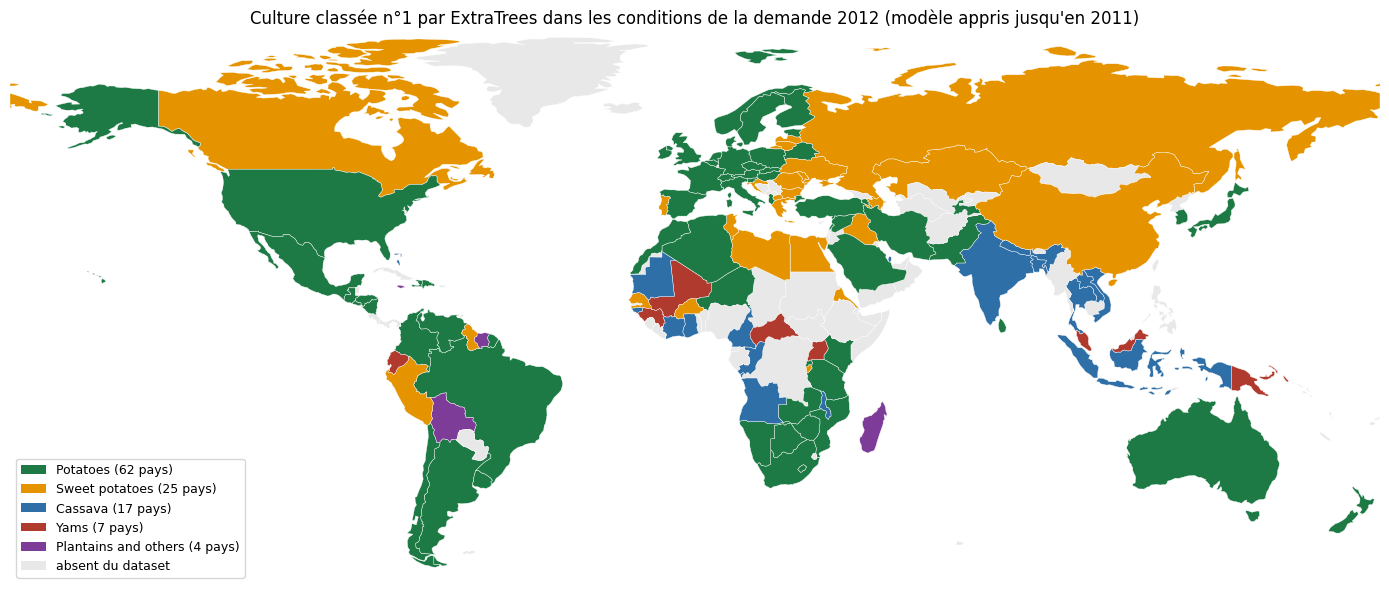

In [8]:
# une couleur par culture classée n°1, légende de la plus à la moins fréquente
COULEURS_TOP1 = ["#1e7a45", "#e59400", "#2e6fa7", "#b03a2e", "#7d3c98", "#17a589", "#d4ac0d", "#6e2c00", "#ec7063",
                 "#1b2631"]
libelles_top1 = {culture: f"{culture} ({n} pays)" for culture, n in REPARTITION_TOP1["pays"].items()}
couleurs_top1 = dict(zip(libelles_top1.values(), COULEURS_TOP1))
categories_top1 = {iso3: libelles_top1[culture] for iso3, culture in TOP1_2012["crop"].items()}
if SANS_DEMANDE_2012:
    categories_top1 |= {iso3: "sans demande 2012 possible" for iso3 in SANS_DEMANDE_2012}
    couleurs_top1["sans demande 2012 possible"] = "#9e9e9e"
plot_carte_categories(categories_top1, couleurs_top1, libelle_absent="absent du dataset",
                      titre="Culture classée n°1 par ExtraTrees dans les conditions de la demande 2012 "
                            "(modèle appris jusqu'en 2011)")

**Observations :**

- Seules cinq cultures arrivent n°1, celles aux rendements moyens les plus élevés en t/ha : pomme de terre (62 pays),
  patate douce (25), manioc (17), igname (7) et plantain (4). Maïs, riz, blé, sorgho et soja ne le sont jamais.
- Manioc, igname et plantain sont n°1 surtout entre les tropiques ; la patate douce couvre de très grands pays
  (Russie, Canada, Chine, Kazakhstan) mais n'est n°1 que dans 25 pays.
- 25 tops 1 sur 115 concernent une culture jamais observée dans le pays avant 2012, dont 16 pour la patate douce.

## Comparaison avec les rendements observés en 2012

Pour chaque pays, le n°1 d'ExtraTrees (demande 2012, modèle appris jusqu'en 2011) est comparé à la culture qui a eu le
meilleur rendement parmi celles réellement observées dans le pays en 2012 (2012 fait partie des années de validation).

même n°1 : 83 sur 115
n°1 jamais observé dans le pays : 25 sur 115
n°1 observé, mais pas le meilleur en 2012 : 7 sur 115

même n°1 en ne classant que les cultures observées dans le pays en 2012 : 105 sur 115
meilleur rendement observé en 2012 dans le top 3 du modèle : 109 sur 115


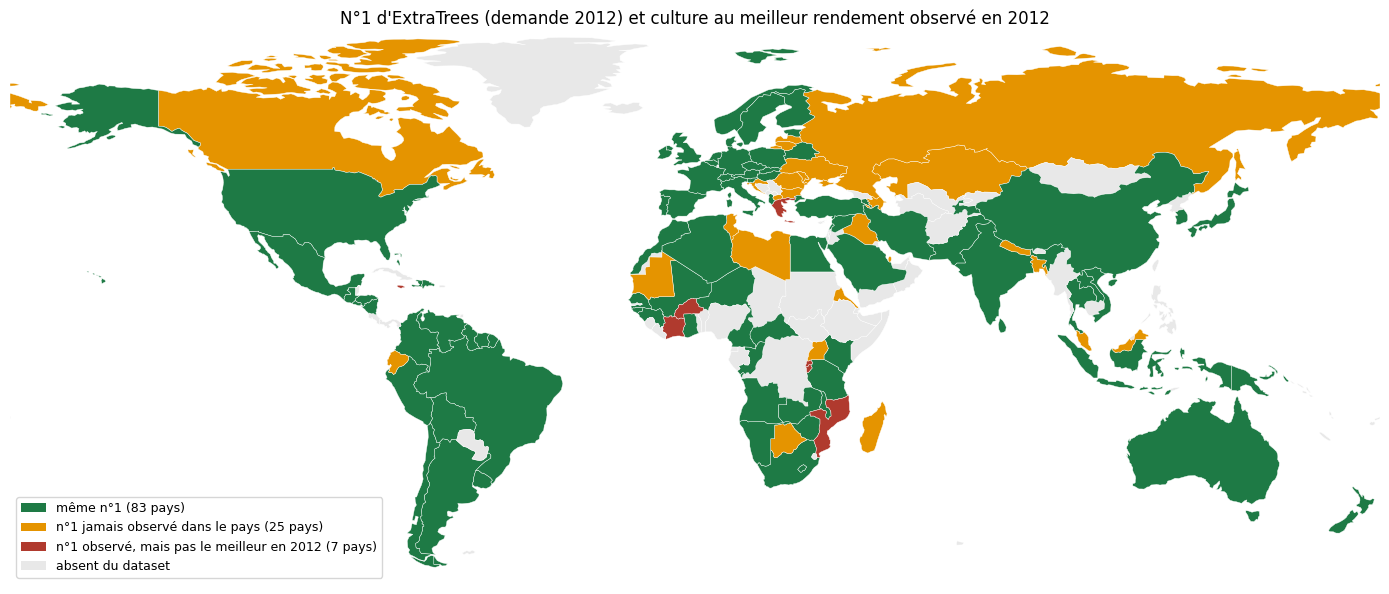

In [9]:
# meilleur rendement observé en 2012 dans chaque pays, comparé au n°1 d'ExtraTrees pour la demande 2012
en_2012 = (X_train["year"] == 2012).to_numpy()
observes_2012 = X_train.loc[en_2012, ["iso3", "crop"]].assign(rendement=y_train[en_2012].to_numpy())
MEILLEUR_2012 = observes_2012.loc[observes_2012.groupby("iso3")["rendement"].idxmax()].set_index("iso3")["crop"]
COULEURS_ACCORD = {"même n°1": "#1e7a45", "n°1 jamais observé dans le pays": "#e59400",
                   "n°1 observé, mais pas le meilleur en 2012": "#b03a2e"}
ACCORD_2012 = pd.Series({
    iso3: "même n°1" if n1 == MEILLEUR_2012[iso3]
    else "n°1 jamais observé dans le pays" if not observe
    else "n°1 observé, mais pas le meilleur en 2012"
    for iso3, n1, observe in zip(TOP1_2012.index, TOP1_2012["crop"], TOP1_2012["couple_observe"])})
comptes_accord = ACCORD_2012.value_counts()
for categorie_accord in COULEURS_ACCORD:
    print(f"{categorie_accord} : {comptes_accord[categorie_accord]} sur {len(ACCORD_2012)}")

# classements complets des 115 demandes, pour deux diagnostics
classements_2012 = {iso3: recommander(MODELES_2012["extra_trees"],
                                      preparer_demande(HISTORIQUE_PAYS, iso3, 2012, coordonnees))
                    for iso3 in TOP1_2012.index}
cultures_2012 = observes_2012.groupby("iso3")["crop"].agg(set)
parmi_observees = sum(
    classement.loc[classement["crop"].isin(cultures_2012[iso3]), "crop"].iloc[0] == MEILLEUR_2012[iso3]
    for iso3, classement in classements_2012.items())
dans_top3 = sum(MEILLEUR_2012[iso3] in set(classement["crop"].head(3)) for iso3, classement in classements_2012.items())
print(f"\nmême n°1 en ne classant que les cultures observées dans le pays en 2012 : {parmi_observees}"
      f" sur {len(ACCORD_2012)}")
print(f"meilleur rendement observé en 2012 dans le top 3 du modèle : {dans_top3} sur {len(ACCORD_2012)}")

libelles_accord = {categorie: f"{categorie} ({n} pays)" for categorie, n in comptes_accord.items()}
plot_carte_categories({iso3: libelles_accord[categorie] for iso3, categorie in ACCORD_2012.items()},
                      {libelles_accord[categorie]: couleur for categorie, couleur in COULEURS_ACCORD.items()},
                      titre="N°1 d'ExtraTrees (demande 2012) et culture au meilleur rendement observé en 2012",
                      libelle_absent="absent du dataset")

**Observations :**

- Dans 83 pays sur 115, la culture classée n°1 par ExtraTrees est aussi celle qui présente le meilleur rendement parmi
  les cultures réellement observées en 2012.
- Parmi les 32 différences, 25 correspondent à une culture classée n°1 mais jamais observée dans le pays ; seules 7
  concernent une culture déjà observée.
- Si le classement est limité aux cultures observées dans le pays en 2012, le même n°1 est retrouvé dans 105 pays sur
  115 ; la culture au meilleur rendement observé apparaît dans le top 3 du modèle dans 109 pays.
- Cette comparaison porte sur une année de validation et ne constitue pas un nouveau test indépendant. Elle permet
  surtout de localiser la principale limite : les cultures que le modèle classe dans des pays où elles n'ont jamais été
  observées.

# Limite : cultures jamais observées dans le pays

Parmi les lignes de la validation temporelle 2008-2012, combien portent sur un couple pays × culture déjà vu pendant
l'apprentissage ?

In [10]:
# validation 2008-2012 : lignes dont le couple pays × culture était déjà dans l'apprentissage du même fold
couples_hist = X_hist[["iso3", "crop"]]
deja_vues = sum(pd.MultiIndex.from_frame(couples_hist.iloc[validation])
                .isin(pd.MultiIndex.from_frame(couples_hist.iloc[apprentissage])).sum()
                for apprentissage, validation in cv_hist)
print(f"lignes de validation dont le couple pays × culture a déjà été vu : {deja_vues}"
      f" sur {sum(len(validation) for _, validation in cv_hist)}")

lignes de validation dont le couple pays × culture a déjà été vu : 3469 sur 3472


**Observations :**

- La carte montre que **25 top 1 sur 115** concernent une culture jamais observée dans le pays avant 2012.
- Or **3 469 des 3 472 lignes de validation** correspondent à un couple pays × culture déjà vu pendant
  l'apprentissage.
- La RMSE d'environ **1,44 t/ha** valide donc essentiellement la prédiction de cultures déjà observées dans un pays.
  Elle ne permet pas de mesurer correctement la qualité des recommandations pour une culture jamais observée dans ce
  pays.

# Sensibilité aux conditions

Dans l'historique disponible, l'écart entre la période de 3 ans la plus chaude et la plus froide d'un même pays n'est
que de 0,9 °C en médiane : trop peu pour voir comment `/recommend` réagit. On applique donc un **stress test** :
des perturbations synthétiques, plus marquées mais plausibles, autour de la demande 2012 des cinq pays, pour les trois
modèles appris jusqu'en 2011 : 8 scénarios × 5 pays × 3 modèles, soit 120 évaluations.

| Scénario | Variable modifiée |
|---|---|
| température −3 °C, +3 °C | `temp_hist`, température moyenne des 3 années précédentes |
| pluie −30 %, +30 % | `rain_mm` ; **scénarios synthétiques** : la pluie est fixe par pays dans le dataset, aucune variation n'a été observée |
| pesticides −50 %, +50 % | tonnage moyen des 3 années précédentes, repassé ensuite en `log1p` comme `log_pest_hist` |
| plus chaud et plus sec, plus froid et plus humide | ±3 °C combinés à ∓30 % de pluie |

Deux cas sortent des températures apprises : Mali +3 °C (31,0 °C, au-delà du maximum de 30,0 °C) et Norvège −3 °C
(−0,1 °C, sous le minimum de 2,6 °C). Un modèle à arbres n'extrapole pas au-delà des seuils appris : il y répond comme
au bord de la plage connue. Ces cas sont signalés « hors plage » ; leurs prédictions ne valident pas ces conditions.

Ce stress test décrit le comportement de `/recommend` : il ne sert pas au choix du modèle.

In [11]:
# plages apprises par MODELES_2012 (lignes avec historique, jusqu'en 2011) : au-delà, un arbre n'extrapole pas
APPRIS = X_hist.loc[AVANT_2012]
PLAGES = {nom: (APPRIS[nom].min(), APPRIS[nom].max()) for nom in ["temp_hist", "rain_mm", "log_pest_hist"]}

# ces conditions varient surtout d'un pays à l'autre (une valeur par pays et par année)
annees = APPRIS.drop_duplicates(["iso3", "year"])
part_pays = 1 - annees.groupby("iso3")["temp_hist"].var(ddof=0).mean() / annees["temp_hist"].var(ddof=0)
ecart_pays = annees.groupby("iso3")["temp_hist"].agg(lambda t: t.max() - t.min()).median()
pluies_par_pays = annees.groupby("iso3")["rain_mm"].nunique().max()
print(f"temp_hist : {part_pays:.1%} de la variance entre pays, écart médian de {ecart_pays:.1f} °C entre la période"
      f" la plus chaude et la plus froide d'un pays | rain_mm : {pluies_par_pays} valeur par pays\n")


def pesticides(demande, facteur):
    "Tonnage moyen de pesticides multiplié par `facteur`, puis repassé en log1p comme `log_pest_hist`."
    return np.log1p(np.expm1(demande["log_pest_hist"]) * facteur)


# scénario : (type de perturbation, modification de la demande 2012)
SCENARIOS = {
    "température −3 °C": ("température", lambda d: d.assign(temp_hist=d["temp_hist"] - 3)),
    "température +3 °C": ("température", lambda d: d.assign(temp_hist=d["temp_hist"] + 3)),
    "pluie −30 %": ("pluie", lambda d: d.assign(rain_mm=d["rain_mm"] * 0.7)),
    "pluie +30 %": ("pluie", lambda d: d.assign(rain_mm=d["rain_mm"] * 1.3)),
    "pesticides −50 %": ("pesticides", lambda d: d.assign(log_pest_hist=pesticides(d, 0.5))),
    "pesticides +50 %": ("pesticides", lambda d: d.assign(log_pest_hist=pesticides(d, 1.5))),
    "+3 °C et pluie −30 %": ("combinés", lambda d: d.assign(temp_hist=d["temp_hist"] + 3, rain_mm=d["rain_mm"] * 0.7)),
    "−3 °C et pluie +30 %": ("combinés", lambda d: d.assign(temp_hist=d["temp_hist"] - 3, rain_mm=d["rain_mm"] * 1.3)),
}


def top3(classement):
    return " > ".join(f"{culture} {rendement:.1f}" for culture, rendement in classement["rendement_predit"].head(3).items())


lignes = {}
for code, pays in PAYS.items():
    for famille, pipeline in MODELES_2012.items():
        reference = recommander(pipeline, DEMANDES[code]).set_index("crop")
        for scenario, (type_, modifier) in SCENARIOS.items():
            demande = modifier(DEMANDES[code])
            classement = recommander(pipeline, demande).set_index("crop")
            lignes[(pays, scenario, famille)] = {
                "type": type_, "top 3 (2012)": top3(reference), "top 3 (scénario)": top3(classement),
                "top 1 identique": classement.index[0] == reference.index[0],
                "top 3 identique": list(classement.index[:3]) == list(reference.index[:3]),  # ordre compris
                "mêmes cultures en top 3": set(classement.index[:3]) == set(reference.index[:3]),
                "rangs changés": int((classement["rang"] != reference["rang"].reindex(classement.index)).sum()),
                "écart moyen (t/ha)": (classement["rendement_predit"] - reference["rendement_predit"]).abs().mean(),
                "hors plage apprise": ", ".join(nom for nom, (bas, haut) in PLAGES.items()
                                                if not bas <= demande[nom].iloc[0] <= haut)}
sensibilite = pd.DataFrame(lignes).T.infer_objects()
sensibilite.index.names = ["pays", "scénario", "modèle"]


def etat(ligne):
    "Ce que devient le top 3, puis l'écart moyen des rendements prédits (t/ha)."
    if not ligne["top 1 identique"]:
        texte = "top 1 changé"
    elif ligne["top 3 identique"]:
        texte = "top 3 identique"
    elif ligne["mêmes cultures en top 3"]:
        texte = "ordre changé"
    else:
        texte = "culture changée"
    return f"{texte} · {ligne['écart moyen (t/ha)']:.2f}" + (" (hors plage)" if ligne["hors plage apprise"] else "")


print("ExtraTrees, modèle retenu : top 3 et écart moyen des rendements (t/ha) par rapport à la demande 2012")
display(sensibilite.xs("extra_trees", level="modèle").apply(etat, axis=1).unstack("pays")
        .reindex(index=list(SCENARIOS), columns=list(PAYS.values())))

# les trois finalistes : scénarios qui changent le top 1 ou le top 3, sur 10 par type (2 scénarios × 5 pays), 40 au total
changements = sensibilite.assign(**{"top 1 changé": ~sensibilite["top 1 identique"],
                                    "top 3 changé": ~sensibilite["top 3 identique"]})
tous = pd.concat([changements, changements.assign(type="total")])
par_type = tous.groupby(["type", "modèle"], sort=False).agg(**{
    "top 1 changé": ("top 1 changé", "sum"), "top 3 changé": ("top 3 changé", "sum"),
    "écart moyen (t/ha)": ("écart moyen (t/ha)", "mean")})
par_type.unstack("modèle").reindex(columns=list(MODELES_2012), level="modèle").round(2)

temp_hist : 99.8% de la variance entre pays, écart médian de 0.9 °C entre la période la plus chaude et la plus froide d'un pays | rain_mm : 1 valeur par pays



ExtraTrees, modèle retenu : top 3 et écart moyen des rendements (t/ha) par rapport à la demande 2012


pays,France,Inde,Mali,Australie,Norvège
scénario,,,,,
température −3 °C,top 3 identique · 0.12,culture changée · 0.77,top 1 changé · 0.80,top 3 identique · 0.84,top 3 identique · 0.04 (hors plage)
température +3 °C,top 3 identique · 0.50,top 3 identique · 0.27,top 3 identique · 0.63 (hors plage),top 3 identique · 1.19,top 3 identique · 0.21
pluie −30 %,top 3 identique · 1.51,top 3 identique · 0.41,top 3 identique · 0.45,top 3 identique · 0.12,top 3 identique · 0.39
pluie +30 %,top 3 identique · 0.37,top 3 identique · 0.60,top 3 identique · 0.27,top 3 identique · 0.39,culture changée · 0.59
pesticides −50 %,top 3 identique · 0.38,top 3 identique · 0.41,top 3 identique · 0.02,top 3 identique · 1.17,top 3 identique · 0.27
pesticides +50 %,top 3 identique · 0.33,top 3 identique · 0.32,top 3 identique · 0.05,top 3 identique · 0.10,top 3 identique · 0.28
+3 °C et pluie −30 %,top 3 identique · 1.68,top 3 identique · 0.62,top 3 identique · 1.03 (hors plage),top 3 identique · 1.18,top 3 identique · 0.56
−3 °C et pluie +30 %,top 3 identique · 0.38,top 3 identique · 1.15,top 1 changé · 0.97,top 3 identique · 1.14,culture changée · 0.63 (hors plage)


top 1 changé                   top 3 changé                    \
modèle       extra_trees catboost lightgbm  extra_trees catboost lightgbm   
type                                                                        
température            1        1        1            2        3        4   
pluie                  0        1        0            1        4        3   
pesticides             0        0        0            0        4        2   
combinés               1        1        1            2        6        5   
total                  2        3        2            5       17       14   

            écart moyen (t/ha)                    
modèle             extra_trees catboost lightgbm  
type                                              
température               0.54     0.88     0.97  
pluie                     0.51     0.77     0.81  
pesticides                0.33     0.43     0.64  
combinés                  0.93     1.50     1.60  
total                     0.58     0.90     1.00

**Observations :**

- **Le classement d'ExtraTrees résiste bien** : son top 3 reste identique, ordre compris, dans 35 scénarios sur 40. Sa
  première culture ne change que deux fois, au Mali, où l'igname et la pomme de terre sont proches ; les trois autres
  changements ne touchent que la 3e place (Inde −3 °C, Norvège avec 30 % de pluie en plus).
- **Les rendements prédits, eux, bougent** : 0,58 t/ha d'écart moyen sur les dix cultures, jusqu'à 1,68 t/ha pour
  « plus chaud et plus sec » en France. Les scénarios de température et de pluie déplacent davantage les prédictions
  que ceux sur les pesticides (0,54 et 0,51 t/ha contre 0,33), qui ne changent aucun top 3.
- **Les prédictions de CatBoost et LightGBM bougent beaucoup plus** : top 3 changé dans 17 et 14 scénarios sur 40,
  écart moyen de 0,90 et 1,00 t/ha. Leur première culture reste en revanche aussi stable (3 et 2 changements).
- **Ces écarts ne démontrent pas un effet agronomique** : 99,8 % de la variance de `temp_hist` est entre pays et
  `rain_mm` est fixe par pays (première ligne affichée). Les modèles ont donc appris ces variables en comparant des
  pays : les modifier rapproche en partie la demande d'autres pays appris, et les variations des prédictions ne
  prouvent pas un effet causal de la température ou de la pluie.
- **Hors plage apprise** : à −3 °C, la Norvège passe sous la température la plus froide du dataset et les prédictions
  d'ExtraTrees ne bougent presque pas (0,04 t/ha) ; combiné à +30 % de pluie, on retrouve presque l'écart de la pluie
  seule (0,63 contre 0,59 t/ha). Au Mali, +3 °C ne peut rien dire au-delà de 30,0 °C : l'écart mesuré correspond au
  passage de 28,0 à 30,0 °C. C'est une limite du modèle à arbres, pas une indication sur ces cultures dans ces
  climats.

## Trois exemples

Choisis après lecture des résultats : une inversion entre deux cultures proches (Mali, −3 °C), un fort changement de
rendement prédit sans changement de classement (France, pluie −30 %), et un désaccord entre les modèles (Australie,
pluie +30 %).

In [12]:
# trois cas choisis après lecture des résultats ci-dessus, pour les trois finalistes
EXEMPLES = [("Mali", "température −3 °C"), ("France", "pluie −30 %"), ("Australie", "pluie +30 %")]
colonnes = ["top 3 (2012)", "top 3 (scénario)", "rangs changés", "écart moyen (t/ha)"]
with pd.option_context("display.max_colwidth", None):  # tops 3 affichés en entier
    display(sensibilite.loc[[(pays, scenario, famille) for pays, scenario in EXEMPLES for famille in MODELES_2012],
                            colonnes].round(2))

top 3 (2012)  \
pays      scénario          modèle                                                                         
Mali      température −3 °C extra_trees                  Yams 23.0 > Potatoes 20.7 > Sweet potatoes 18.2   
                            catboost                     Yams 22.8 > Potatoes 20.5 > Sweet potatoes 18.1   
                            lightgbm               Yams 22.8 > Potatoes 21.1 > Plantains and others 19.0   
France    pluie −30 %       extra_trees                  Potatoes 45.0 > Sweet potatoes 18.9 > Yams 16.0   
                            catboost                     Potatoes 46.2 > Sweet potatoes 17.3 > Yams 12.3   
                            lightgbm               Potatoes 45.9 > Plantains and others 27.7 > Yams 25.9   
Australie pluie +30 %       extra_trees                  Potatoes 35.5 > Sweet potatoes 31.0 > Yams 17.5   
                            catboost                  Potatoes 35.0 > Sweet potatoes 31.9 > Cassava 11.8   
                            lightgbm     Potatoes 35.0 > Sweet potatoes 31.5 > Plantains and others 28.0   

                                                                                        top 3 (scénario)  \
pays      scénario          modèle                                                                         
Mali      température −3 °C extra_trees                  Potatoes 20.0 > Yams 19.0 > Sweet potatoes 18.5   
                            catboost                     Potatoes 18.1 > Sweet potatoes 17.8 > Yams 17.8   
                            lightgbm                     Potatoes 15.5 > Sweet potatoes 14.2 > Yams 13.6   
France    pluie −30 %       extra_trees                  Potatoes 34.3 > Sweet potatoes 19.3 > Yams 15.9   
                            catboost                     Potatoes 38.9 > Sweet potatoes 19.5 > Yams 11.4   
                            lightgbm               Potatoes 37.6 > Plantains and others 23.2 > Yams 21.5   
Australie pluie +30 %       extra_trees                  Potatoes 34.2 > Sweet potatoes 29.4 > Yams 17.5   
                            catboost                     Sweet potatoes 24.5 > Potatoes 23.8 > Yams 12.2   
                            lightgbm     Potatoes 34.6 > Sweet potatoes 30.2 > Plantains and others 27.3   

                                         rangs changés  écart moyen (t/ha)  
pays      scénario          modèle                                          
Mali      température −3 °C extra_trees              4                0.80  
                            catboost                 5                1.22  
                            lightgbm                 8                3.21  
France    pluie −30 %       extra_trees              2                1.51  
                            catboost                 2                1.45  
                            lightgbm                 4                2.73  
Australie pluie +30 %       extra_trees              2                0.39  
                            catboost                 4                2.67  
                            lightgbm                 0                0.58

**Observations :**

- **Mali, −3 °C** : l'igname (23,0 t/ha) et la pomme de terre (20,7) sont proches ; dans ce scénario, les trois modèles
  placent la pomme de terre en tête. ExtraTrees inverse simplement les deux (20,0 contre 19,0), alors que LightGBM
  prédit l'igname à 13,6 t/ha au lieu de 22,8 et change 8 rangs sur 10.
- **France, pluie −30 %** : le rendement prédit de la pomme de terre passe de 45,0 à 34,3 t/ha avec ExtraTrees (7 à
  8 t/ha de moins avec les deux autres), mais aucun top 3 ne bouge : son avance sur la deuxième culture reste très
  grande.
- **Australie, pluie +30 %** : ExtraTrees et LightGBM gardent leur top 3 (0,39 et 0,58 t/ha d'écart moyen), alors que
  CatBoost classe la patate douce devant la pomme de terre, prédite à 23,8 t/ha au lieu de 35,0. La pluie étant fixe
  par pays, les modèles l'ont apprise en comparant des pays : la modifier rapproche l'Australie d'autres pays, et les
  prédictions de CatBoost y réagissent beaucoup plus fort.

# Compromis performance / taille d'ExtraTrees

Le modèle du notebook 14 pèse 121,6 Mo compressés, au-dessus de la limite de 100 Mo par fichier de GitHub. On cherche
donc le meilleur compromis entre performance et taille. Retirer des arbres n'est pas la seule piste : d'autres réglages
(`max_depth`, `min_samples_split`, `min_samples_leaf`, `max_leaf_nodes`, `max_features`) peuvent réduire la taille de
chaque arbre.

Les outils de mesure sont dans `agritech.forest_size` ; le notebook garde la grille, les résultats et les décisions.

In [13]:
# les outils de mesure sont dans `agritech.forest_size` ; ici, seulement les contrôles qui les valident
POINTS = [50, 75, 100, 125, 150, 175, 200, 250, 300, 400, 500, 600, 800, 1000, 1200]
BUDGET_NOEUDS = 9_000_000  # au-delà, le fichier dépasse 200 Mo : hors sujet pour un compromis de taille
REFERENCE = {cle: valeur for cle, valeur in RECOMMEND_FINALISTS["extra_trees"]["params"].items() if cle != "n_estimators"}
PLIS, X_ENCODE, Y, ENCODEUR = MATRICES = preparer_matrices(X_hist, y_hist, cv_hist, CATEGORIELLES, NUMERIQUES)

# les raccourcis doivent donner exactement les mêmes nombres qu'un apprentissage direct
rapide = float(np.mean([scores_par_prefixe(foret(300, **REFERENCE).fit(X_app, y_app), X_val, y_val, {300})[300][0]
                        for X_app, y_app, X_val, y_val in PLIS]))
X_app, y_app, X_val, y_val = PLIS[-1]
entiere, directe = foret(300, **REFERENCE).fit(X_app, y_app), foret(150, **REFERENCE).fit(X_app, y_app)
assert abs(rapide - mesures["extra_trees"]["RMSE"]) < 1e-9, "chemin rapide différent du pipeline"
assert np.abs(tronquer(entiere, 150).predict(X_val) - directe.predict(X_val)).max() == 0, "troncature différente"
with tempfile.TemporaryDirectory() as dossier:
    ecart = abs(taille(deployable(ENCODEUR, tronquer(entiere, 150)), dossier, "a.joblib")
                - taille(deployable(ENCODEUR, directe), dossier, "b.joblib"))
print(f"RMSE de la référence : chemin rapide {rapide:.6f} | notebook {mesures['extra_trees']['RMSE']:.6f}")
print(f"150 arbres tronqués contre 150 arbres appris : mêmes prédictions, écart de taille {ecart:.3f} Mo")

RMSE de la référence : chemin rapide 1.435889 | notebook 1.435889
150 arbres tronqués contre 150 arbres appris : mêmes prédictions, écart de taille 0.000 Mo


## Ce qui fait la taille

D'abord ce qui fait grossir le fichier, puis l'effet du seul nombre d'arbres.

In [14]:
# mêmes 100 arbres, structures différentes (la référence est aussi donnée à 300 arbres)
ANATOMIE = {
    "référence, 300 arbres": (300, REFERENCE),
    "référence, 100 arbres": (100, REFERENCE),
    "max_features 0.6": (100, {"max_features": 0.6, "min_samples_split": 3}),
    "min_samples_split 10": (100, {"max_features": 0.9, "min_samples_split": 10}),
    "min_samples_leaf 2": (100, {"max_features": 0.9, "min_samples_leaf": 2}),
    "min_samples_leaf 4": (100, {"max_features": 0.9, "min_samples_leaf": 4}),
    "max_depth 20": (100, {"max_features": 0.9, "min_samples_split": 3, "max_depth": 20}),
    "max_leaf_nodes 1000": (100, {"max_features": 0.9, "min_samples_split": 3, "max_leaf_nodes": 1000}),
    "max_leaf_nodes 4000": (100, {"max_features": 0.9, "min_samples_split": 3, "max_leaf_nodes": 4000}),
}
lignes = []
with tempfile.TemporaryDirectory() as dossier:
    for nom, (arbres, params) in ANATOMIE.items():
        pipeline = deployable(ENCODEUR, foret(arbres, **params).fit(X_ENCODE, Y))
        lignes.append({"configuration": nom, **structure(pipeline["model"]),
                       **mesurer_artefact(pipeline, demande_chrono, dossier, formats=("zlib", "lzma"))})

anatomie = pd.DataFrame(lignes).set_index("configuration")
for colonne in ["brut (Mo)", "zlib (Mo)", "lzma (Mo)"]:
    octets = anatomie[colonne] * 1e6 / anatomie["noeuds"]
    print(f"{colonne:11s} : {octets.mean():5.1f} octets par nœud en moyenne, de {octets.min():.1f} à {octets.max():.1f}")
anatomie.round(2)

brut (Mo)   :  72.1 octets par nœud en moyenne, de 72.0 à 72.2
zlib (Mo)   :  22.7 octets par nœud en moyenne, de 20.6 à 26.1
lzma (Mo)   :  16.5 octets par nœud en moyenne, de 15.1 à 18.2


,arbres,noeuds,noeuds par arbre,feuilles par arbre,profondeur moyenne,profondeur max,brut (Mo),zlib (Mo),lzma (Mo),chargement zlib (s),chargement lzma (s),10 cultures (ms)
configuration,,,,,,,,,,,,
"référence, 300 arbres",300,5901766,19673,9837,31.9,37,425.02,121.59,89.26,0.47,2.51,8.70
"référence, 100 arbres",100,1967654,19677,9839,31.9,37,141.71,40.54,29.79,0.15,0.83,3.32
max_features 0.6,100,1982562,19826,9913,32.5,40,142.78,40.90,30.43,0.15,0.85,3.31
min_samples_split 10,100,575290,5753,2877,27.9,32,41.46,13.95,10.36,0.06,0.29,3.28
min_samples_leaf 2,100,1087266,10873,5437,29.0,33,78.32,25.08,18.39,0.09,0.53,3.33
min_samples_leaf 4,100,466272,4663,2332,26.2,30,33.61,11.57,8.50,0.04,0.24,3.39
max_depth 20,100,1483408,14834,7418,20.0,20,106.84,31.36,22.99,0.13,0.68,3.37
max_leaf_nodes 1000,100,199900,1999,1000,22.1,30,14.43,5.21,3.54,0.02,0.10,3.41
max_leaf_nodes 4000,100,799900,7999,4000,28.3,39,57.63,18.39,12.88,0.07,0.36,3.47


In [15]:
# effet du seul nombre d'arbres, à structure fixée (celle du notebook 14)
with tempfile.TemporaryDirectory() as dossier:
    complet = foret(500, **REFERENCE).fit(X_ENCODE, Y)
    noeuds = np.cumsum([arbre.tree_.node_count for arbre in complet.estimators_])
    taille_500 = taille(deployable(ENCODEUR, complet), dossier, "m.joblib")
points = [50, 75, 100, 125, 150, 175, 200, 225, 250, 275, 300, 350, 400, 500]
plis = [scores_par_prefixe(foret(500, **REFERENCE).fit(X_app, y_app), X_val, y_val, set(points))
        for X_app, y_app, X_val, y_val in PLIS]
courbe = pd.DataFrame([{"arbres": k,
                        "RMSE": np.mean([pli[k][0] for pli in plis]),
                        "MAE": np.mean([pli[k][1] for pli in plis]),
                        "écart-type annuel": np.std([pli[k][0] for pli in plis]),
                        "nœuds": int(noeuds[k - 1]),
                        "taille (Mo)": taille_500 * noeuds[k - 1] / noeuds[-1]} for k in points]).set_index("arbres")
print(f"meilleure RMSE à {courbe['RMSE'].idxmin()} arbres ({courbe['RMSE'].min():.4f}), "
      f"soit {courbe.loc[courbe['RMSE'].idxmin(), 'taille (Mo)']:.1f} Mo")
courbe.round({"RMSE": 4, "MAE": 4, "écart-type annuel": 4, "taille (Mo)": 1})

meilleure RMSE à 150 arbres (1.4349), soit 60.8 Mo


,RMSE,MAE,écart-type annuel,nœuds,taille (Mo)
arbres,,,,,
50,1.4537,0.7189,0.1327,983470,20.3
75,1.4445,0.7155,0.1290,1475689,30.4
100,1.4390,0.7133,0.1298,1967654,40.5
125,1.4360,0.7117,0.1283,2459353,50.7
150,1.4349,0.7114,0.1284,2950658,60.8
175,1.4361,0.7114,0.1273,3442301,70.9
200,1.4366,0.7122,0.1263,3934112,81.0
225,1.4370,0.7121,0.1276,4425729,91.2
250,1.4367,0.7125,0.1282,4917850,101.3


**Observations :**

- La taille du fichier ne dépend que du **nombre total de nœuds** : 72 octets par nœud avant compression, quelle que
  soit la structure. 300 arbres pèsent donc trois fois plus que 100.
- `max_features` ne change rien à la taille. Ce qui la réduit, ce sont les réglages qui arrêtent la croissance des
  arbres : `max_leaf_nodes`, `min_samples_leaf`, `min_samples_split` et `max_depth` retirent ici de 25 % à 90 % des
  nœuds.
- Compresser divise la taille par 3,5 en zlib et par 4,8 en lzma. `lzma` suffirait à passer sous 100 Mo sans toucher
  au modèle (89,3 Mo), mais le chargement passe de 0,5 à 2,5 s.
- Le temps de prédiction suit le nombre d'arbres, pas la taille : 3,3 ms pour 100 arbres, 8,7 ms pour 300.
- **Le nombre d'arbres suffit déjà** : la RMSE descend jusqu'à 150 arbres (1,4349, 60,8 Mo) puis ne bouge plus. Le
  modèle du notebook 14 (300 arbres, 121,6 Mo) est au-delà du point utile. En dessous de 100 arbres, la perte devient
  visible (1,4390 à 100 arbres, 1,4537 à 50).

## Recherche à deux critères

On cherche à réduire à la fois la RMSE et la taille du fichier. Le **front de Pareto** regroupe les meilleurs
compromis : aucun autre modèle évalué n'est à la fois plus petit et meilleur en RMSE. C'est la courbe verte du
graphique ci-dessous.

La recherche se fait en trois temps : 2 000 configurations de la grille, presque toutes tirées au sort, puis deux
tours autour des meilleurs compromis, en décalant un réglage d'un cran.

Deux raccourcis, vérifiés plus haut, rendent ce calcul possible : les `k` premiers arbres d'une forêt forment une
forêt de `k` arbres, et la taille du fichier se déduit du nombre de nœuds. Un seul apprentissage par fold donne donc
tous les nombres d'arbres.

In [16]:
GRILLE = {
    "max_features": [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    "min_samples_split": [2, 3, 4, 5, 6, 8, 10, 14, 20],
    "min_samples_leaf": [1, 2, 3, 4, 6, 8],
    "max_depth": [15, 20, 25, 30, 35, 40, None],       # None = aucune limite, donc au bout de la liste
    "max_leaf_nodes": [250, 500, 1000, 2000, 4000, 8000, None],
}
EXPLORATION = 2000

# les arbres entiers sont la famille du notebook 14 : on les prend tous, le reste est tiré au sort
entiers = list(dict.fromkeys(
    normaliser({"max_features": mf, "min_samples_split": mss, "min_samples_leaf": msl,
                "max_depth": None, "max_leaf_nodes": None})
    for mf in GRILLE["max_features"] for mss in GRILLE["min_samples_split"] for msl in GRILLE["min_samples_leaf"]))
tirage = np.random.default_rng(SEED)
tirees = [normaliser({nom: GRILLE[nom][indice] for nom, indice in
                      zip(GRILLE, tirage.integers(0, [len(valeurs) for valeurs in GRILLE.values()]))})
          for _ in range(8000)]
cles = list(dict.fromkeys(entiers + tirees))[:EXPLORATION]
print(f"exploration : {sum(1 for cle in cles if cle in set(entiers))} configurations à arbres entiers "
      f"et {sum(1 for cle in cles if cle not in set(entiers))} tirées au sort dans le reste de la grille", flush=True)

debut, resultats, tours = time.perf_counter(), lancer(cles, MATRICES, POINTS, BUDGET_NOEUDS, ANNEES), [len(cles)]
faites = set(cles)
for tour in range(2):  # deux tours de raffinement autour des meilleurs compromis
    nouvelles = [cle for cle in voisins(pareto(resultats), GRILLE) if cle not in faites]
    faites.update(nouvelles)
    tours.append(len(nouvelles))
    resultats = pd.concat([resultats, lancer(nouvelles, MATRICES, POINTS, BUDGET_NOEUDS, ANNEES)], ignore_index=True)

verif = resultats.dropna(subset=["taille_mesuree"])
ecart = ((verif["taille"] - verif["taille_mesuree"]).abs() / verif["taille_mesuree"]).max() * 100
print(f"{len(faites)} configurations ({' + '.join(map(str, tours))}), {len(resultats)} modèles évalués, "
      f"{(time.perf_counter() - debut) / 60:.0f} min")
print(f"tailles déduites contre {len(verif)} tailles mesurées : écart maximum {ecart:.3f} %")

exploration : 180 configurations à arbres entiers et 1820 tirées au sort dans le reste de la grille


2369 configurations (2000 + 231 + 138), 35022 modèles évalués, 172 min
tailles déduites contre 4738 tailles mesurées : écart maximum 0.479 %


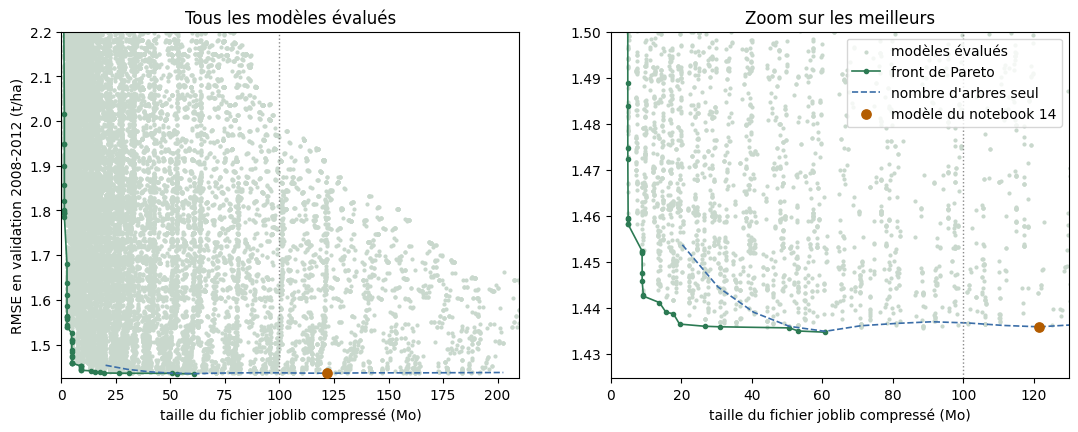

69 meilleurs compromis retenus, de 0.7 à 60.8 Mo


In [17]:
# les meilleurs compromis : aucun autre modèle n'est à la fois plus petit et meilleur en RMSE
compromis = pareto(resultats)
COULEURS = {"nuage": "#c9d8cd", "compromis": "#2c7a53", "reference": "#b35c00"}
REFERENCE_TAILLE, REFERENCE_RMSE = float(courbe.loc[300, "taille (Mo)"]), float(courbe.loc[300, "RMSE"])

figure, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for axe, (xmax, ymax) in zip(axes, [(210, 2.2), (130, 1.50)]):
    axe.scatter(resultats["taille"], resultats["rmse"], s=4, color=COULEURS["nuage"], label="modèles évalués")
    axe.plot(compromis["taille"], compromis["rmse"], color=COULEURS["compromis"], marker="o", ms=3, lw=1.2,
             label="front de Pareto")
    axe.plot(courbe["taille (Mo)"], courbe["RMSE"], color="#3b6ea8", lw=1.2, ls="--", label="nombre d'arbres seul")
    axe.scatter([REFERENCE_TAILLE], [REFERENCE_RMSE], color=COULEURS["reference"], s=45, zorder=4,
                label="modèle du notebook 14")
    axe.axvline(100, color="#8a8a8a", ls=":", lw=1)
    axe.set_xlim(0, xmax); axe.set_ylim(compromis["rmse"].min() - 0.01, ymax)
    axe.set_xlabel("taille du fichier joblib compressé (Mo)")
axes[0].set_ylabel("RMSE en validation 2008-2012 (t/ha)")
axes[0].set_title("Tous les modèles évalués")
axes[1].set_title("Zoom sur les meilleurs")
axes[1].legend(loc="upper right")
plt.show()

print(f"{len(compromis)} meilleurs compromis retenus, de {compromis['taille'].min():.1f} "
      f"à {compromis['taille'].max():.1f} Mo")

In [18]:
# ce que coûte chaque palier de taille
PALIERS = {"meilleur absolu": np.inf, "sous 120 Mo": 120, "sous 100 Mo": 100, "sous 90 Mo": 90,
           "sous 75 Mo": 75, "sous 50 Mo": 50, "sous 25 Mo": 25}
choisis = {}
for nom, plafond in PALIERS.items():
    candidats = resultats[resultats["taille"] <= plafond]
    choisis[nom] = candidats.loc[candidats["rmse"].idxmin()]

paliers = pd.DataFrame(choisis).T
paliers["écart à la référence"] = paliers["rmse"] - REFERENCE_RMSE
colonnes = ["n_estimators", *STRUCTURELS, "taille", "rmse", "écart à la référence", "mae", "rmse_std",
            *[f"rmse_{annee}" for annee in ANNEES]]
paliers[colonnes].astype({"n_estimators": int}).round(
    {"taille": 1, "rmse": 4, "écart à la référence": 4, "mae": 4, "rmse_std": 3,
     **{f"rmse_{annee}": 3 for annee in ANNEES}})

,n_estimators,max_features,min_samples_split,min_samples_leaf,max_depth,max_leaf_nodes,taille,rmse,écart à la référence,mae,rmse_std,rmse_2008,rmse_2009,rmse_2010,rmse_2011,rmse_2012
meilleur absolu,150,0.9,3.0,1.0,35.0,NaN,60.8,1.4347,-0.0012,0.7113,0.128,1.224,1.449,1.373,1.546,1.582
sous 120 Mo,150,0.9,3.0,1.0,35.0,NaN,60.8,1.4347,-0.0012,0.7113,0.128,1.224,1.449,1.373,1.546,1.582
sous 100 Mo,150,0.9,3.0,1.0,35.0,NaN,60.8,1.4347,-0.0012,0.7113,0.128,1.224,1.449,1.373,1.546,1.582
sous 90 Mo,150,0.9,3.0,1.0,35.0,NaN,60.8,1.4347,-0.0012,0.7113,0.128,1.224,1.449,1.373,1.546,1.582
sous 75 Mo,150,0.9,3.0,1.0,35.0,NaN,60.8,1.4347,-0.0012,0.7113,0.128,1.224,1.449,1.373,1.546,1.582
sous 50 Mo,175,0.9,2.0,1.0,25.0,4000.0,31.0,1.4359,0.0000,0.7256,0.132,1.218,1.451,1.371,1.562,1.578
sous 25 Mo,50,1.0,2.0,1.0,20.0,NaN,19.5,1.4365,0.0006,0.7107,0.138,1.223,1.418,1.370,1.581,1.591


**Observations :**

- **Aucun modèle de plus de 60,8 Mo ne fait partie des meilleurs compromis.** Le meilleur des 35 022 modèles évalués
  fait 60,8 Mo (150 arbres, `max_depth` 35) pour une RMSE de 1,4347 : 0,0012 de mieux que le modèle du notebook 14,
  et deux fois plus petit. Les paliers 120, 100, 90 et 75 Mo donnent tous ce modèle. Plus bas, la courbe reste presque
  plate : 31,0 Mo pour 1,4359, 19,5 Mo pour 1,4365, avec la meilleure MAE de l'étude.
- **Ces écarts sont négligeables** : quelques millièmes de RMSE, alors que la RMSE varie d'environ 0,13 t/ha d'une
  année de validation à l'autre. Entre 20 et 200 Mo, la performance est pratiquement la même : la taille devient un
  choix libre.
- Les réglages de structure n'apportent rien au-dessus de 50 Mo : les meilleurs compromis s'y confondent avec la
  courbe du nombre d'arbres. Ils servent en dessous, où brider les arbres permet d'en garder plus pour la même place.
- Les tailles de ces modèles sont déduites du nombre de nœuds (écart maximum 0,479 % sur 4 738 tailles écrites) ;
  celles des modèles retenus ci-dessous sont mesurées.

## Les trois finalistes à la même mesure

Les tailles du notebook 14 étaient brutes. On remesure les trois finalistes : fichier compressé, chargement et temps
d'une demande de 10 cultures.

In [19]:
# les trois finalistes mesurés de la même façon : taille compressée, chargement, temps de prédiction
ENTIER = {**REFERENCE, "min_samples_leaf": 1, "max_depth": None, "max_leaf_nodes": None}
RETENUS = {"ExtraTrees notebook 14": (300, ENTIER, REFERENCE_RMSE, float(courbe.loc[300, "MAE"])),
           "ExtraTrees sous 100 Mo": reglages_depuis(choisis["sous 100 Mo"]),
           "ExtraTrees sous 50 Mo": reglages_depuis(choisis["sous 50 Mo"]),
           "CatBoost": None, "LightGBM": None}
lignes = []
with tempfile.TemporaryDirectory() as dossier:
    for nom, retenu in RETENUS.items():
        if retenu is None:  # CatBoost et LightGBM : les pipelines déjà entraînés plus haut
            famille = nom.lower()
            pipeline, rmse, mae = PIPELINES[famille], mesures[famille]["RMSE"], mesures[famille]["MAE"]
            reglage = RECOMMEND_FINALISTS[famille]["params"]
        else:
            arbres, params, rmse, mae = retenu
            pipeline = deployable(ENCODEUR, foret(arbres, **params).fit(X_ENCODE, Y))
            reglage = {"n_estimators": arbres, **params}
        lignes.append({"modèle": nom, "RMSE": rmse, "MAE": mae,
                       **mesurer_artefact(pipeline, demande_chrono, dossier)})
        print(f"{nom:24s} {reglage}", flush=True)

comparaison = pd.DataFrame(lignes).set_index("modèle").rename(columns={"chargement zlib (s)": "chargement (s)"})
comparaison.round({"RMSE": 3, "MAE": 3, "brut (Mo)": 1, "zlib (Mo)": 1, "lzma (Mo)": 1,
                   "chargement (s)": 2, "10 cultures (ms)": 1})

ExtraTrees notebook 14   {'n_estimators': 300, 'max_features': 0.9, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_depth': None, 'max_leaf_nodes': None}


ExtraTrees sous 100 Mo   {'n_estimators': 150, 'max_features': 0.9, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_depth': 35, 'max_leaf_nodes': None}


ExtraTrees sous 50 Mo    {'n_estimators': 175, 'max_features': 0.9, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 25, 'max_leaf_nodes': 4000}


CatBoost                 {'iterations': 1000, 'learning_rate': 0.2, 'depth': 12, 'l2_leaf_reg': 3}


LightGBM                 {'n_estimators': 1500, 'learning_rate': 0.1, 'num_leaves': 127, 'min_child_samples': 10, 'subsample': 0.7, 'subsample_freq': 1, 'reg_lambda': 20.0}


,RMSE,MAE,brut (Mo),zlib (Mo),lzma (Mo),chargement (s),10 cultures (ms)
modèle,,,,,,,
ExtraTrees notebook 14,1.436,0.713,425.0,121.6,89.3,0.50,8.9
ExtraTrees sous 100 Mo,1.435,0.711,212.5,60.8,44.7,0.23,4.7
ExtraTrees sous 50 Mo,1.436,0.726,100.8,31.0,21.5,0.13,5.4
CatBoost,1.450,0.740,65.4,3.5,2.7,0.02,1.1
LightGBM,1.465,0.757,17.5,6.8,5.5,0.06,2.3


**Observations :**

- Compressés, les trois finalistes changent d'ordre de grandeur : CatBoost passe de 65 à **3,5 Mo** (il compresse
  19 fois), LightGBM de 17,5 à 6,8, alors qu'ExtraTrees ne compresse que 3,5 fois. Les tailles brutes comparaient des
  choses très différentes.
- Trois ExtraTrees tiennent sous la limite de 100 Mo : **60,8 Mo pour la meilleure RMSE de l'étude**, 31,0 Mo pour une
  RMSE équivalente à celle du notebook 14, 19,5 Mo pour 0,0006 de plus. Aucun n'a besoin de Git LFS.
- Le temps de prédiction est surtout une question de `n_jobs` : le modèle du notebook 14 met 18 ms avec `n_jobs=-1`
  mais 8,9 ms ici avec un seul fil, et celui à 150 arbres 4,7 ms. **Le modèle sauvegardé pour l'API doit avoir
  `n_jobs=1`.** CatBoost reste le plus économique (3,5 Mo, 1,1 ms) pour 0,014 t/ha de RMSE en plus.

# Choix du modèle final

Synthèse des critères disponibles avant 2013 : RMSE et MAE en validation, stabilité d'une année à l'autre, taille et
déploiement, simplicité de déploiement et d'explication. Les diagnostics des sections précédentes (cinq pays, carte
mondiale, comparaison avec 2012, limite des cultures jamais observées et stress test) décrivent le comportement et les
limites de `/recommend` : ils ne servent pas à ce choix.

In [20]:
# taille et temps de prédiction : voir le tableau de la section précédente, mesuré sur les fichiers compressés
BIBLIOTHEQUE = {"extra_trees": "scikit-learn", "catboost": "catboost", "lightgbm": "lightgbm"}
synthese = {}
for famille in FINALISTES:
    synthese[famille] = {
        "RMSE CV": finalistes.loc[famille, "RMSE"], "MAE CV": finalistes.loc[famille, "MAE"],
        "écart-type des RMSE par année": round(float(np.std([finalistes.loc[famille, annee] for annee in ANNEES])), 3),
        "bibliothèque": BIBLIOTHEQUE[famille]}

pd.DataFrame(synthese).T

,RMSE CV,MAE CV,écart-type des RMSE par année,bibliothèque
extra_trees,1.436,0.713,0.129,scikit-learn
catboost,1.45,0.74,0.143,catboost
lightgbm,1.465,0.757,0.137,lightgbm


**Modèle retenu : ExtraTrees à 150 arbres** (`max_features` 0,9, `min_samples_split` 3).

- **La famille.** ExtraTrees a la meilleure RMSE (1,436) et la meilleure MAE (0,713) en validation, et il est le plus
  stable d'une année à l'autre (écart-type des RMSE 0,129). Il ne demande que scikit-learn, déjà nécessaire au
  prétraitement : une dépendance de moins pour l'API, et le modèle le plus simple à expliquer, une moyenne d'arbres
  tirés au hasard.
- **Les réglages.** 150 arbres font aussi bien que 300 (1,4349 contre 1,4359, un écart négligeable) pour **60,8 Mo au
  lieu de 121,6** : deux fois plus petit, sous la limite de 100 Mo par fichier de GitHub, plus rapide à charger et à
  prédire.
- On garde ce modèle plutôt que le meilleur de la recherche, qui ajoutait `max_depth=35` pour gagner 0,0002 t/ha : un
  gain négligeable, pour un réglage de plus à justifier.
- **Déploiement.** Sauvegarde en `zlib` (`compress=3`) : `lzma` donnerait 45 Mo, mais se charge cinq fois plus
  lentement, pour un gain inutile une fois sous la limite. Et le modèle est appris avec `n_jobs=1` : sur une demande
  de 10 cultures, répartir le travail sur douze cœurs coûte plus que ça ne rapporte.

Le choix est **figé** : les réglages ci-dessous ne changeront plus, quoi que donne 2013.

In [21]:
# choix figé : à partir d'ici, aucun réglage ni changement de modèle, quoi que donne 2013
MODELE_FINAL = "extra_trees"
REGLAGES_FINAUX = {"n_estimators": 150, "max_features": 0.9, "min_samples_split": 3}
folds_finaux, METRIQUES_CV = run_experiment(foret(**REGLAGES_FINAUX), X_hist, y_hist, cv_hist,
                                            CATEGORIELLES, NUMERIQUES, verbose=False)
PIPELINE_FINAL = deployable(ENCODEUR, foret(**REGLAGES_FINAUX).fit(X_ENCODE, Y))  # appris sur 1991-2012, un seul fil
COUPLES_ENTRAINEMENT = couples_observes(X_hist)  # les lignes réellement apprises, pas tout X_train
with tempfile.TemporaryDirectory() as dossier:
    TAILLE_FINALE = taille(PIPELINE_FINAL, dossier, "recommend_model.joblib")

print(f"modèle final : {MODELE_FINAL} | réglages : {REGLAGES_FINAUX | {'random_state': SEED, 'n_jobs': 1}}")
print(f"variables    : {CATEGORIELLES + NUMERIQUES}")
print(f"validation 2008-2012 : RMSE {METRIQUES_CV['cv_rmse_mean']:.4f} | MAE {METRIQUES_CV['cv_mae_mean']:.4f}"
      f" | R² {METRIQUES_CV['cv_r2_mean']:.3f}")
print(f"fichier joblib compressé : {TAILLE_FINALE:.1f} Mo")

modèle final : extra_trees | réglages : {'n_estimators': 150, 'max_features': 0.9, 'min_samples_split': 3, 'random_state': 42, 'n_jobs': 1}
variables    : ['crop', 'year', 'temp_hist', 'rain_mm', 'log_pest_hist', 'lat_abs', 'geo_x', 'geo_y', 'geo_z']
validation 2008-2012 : RMSE 1.4349 | MAE 0.7114 | R² 0.971
fichier joblib compressé : 60.8 Mo


# Importance des variables du modèle final

Importance par permutation, par famille de variables, comme au notebook 13 : pour chaque année de validation
2008-2012, le modèle final est réappris sur les années précédentes, puis une famille de variables est mélangée dans
l'année de validation ; on mesure la hausse de la RMSE (10 tirages). `year` est constante à l'intérieur d'une année de
validation : la mélanger ne change rien, son rôle est donc mesuré en réapprenant le modèle sans elle. 2013 n'est pas
utilisée.

Ces importances décrivent l'usage des variables par le modèle, pas un effet causal. La géographie, la pluie, la
température et les pesticides sont des valeurs du pays : elles portent en partie le même signal, et le modèle peut
se le partager entre elles.

sans year : RMSE de validation 1.8299 contre 1.4349 avec, soit +0.3950 t/ha


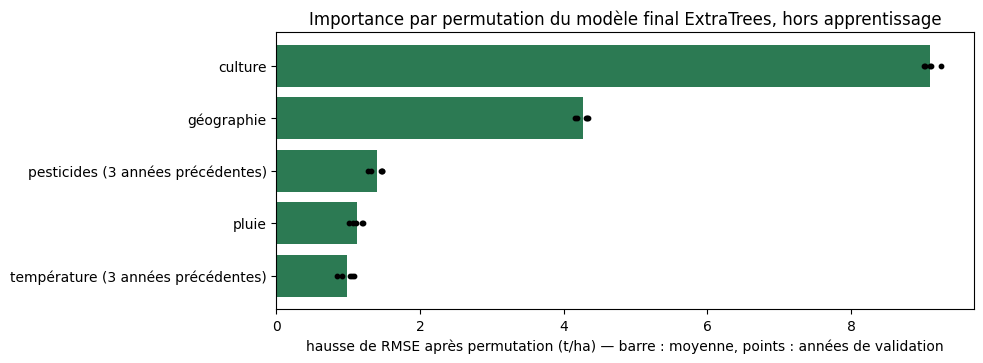

année,2008,2009,2010,2011,2012,moyenne
famille,,,,,,
culture,9.027,9.248,9.018,9.099,9.111,9.101
géographie,4.329,4.338,4.163,4.309,4.184,4.265
pesticides (3 années précédentes),1.452,1.474,1.280,1.470,1.310,1.397
pluie,1.111,1.187,1.210,1.062,1.015,1.117
température (3 années précédentes),1.085,1.029,0.916,1.054,0.836,0.984


In [22]:
# modèle final réappris sur chaque année de validation, familles mélangées hors apprentissage ; 2013 n'intervient pas
FAMILLES_FINALES = {
    "culture": ["crop"],
    "température (3 années précédentes)": ["temp_hist"],
    "pesticides (3 années précédentes)": ["log_pest_hist"],
    "pluie": ["rain_mm"],
    "géographie": RECOMMEND_GEOGRAPHY,
}
importances_finales = permutation_importance_by_family(
    experiment_pipeline(foret(**REGLAGES_FINAUX), CATEGORIELLES, NUMERIQUES), X_hist[CATEGORIELLES + NUMERIQUES],
    y_hist, cv_hist, FAMILLES_FINALES, n_repeats=10, fold_labels=ANNEES)
par_annee_finale = importances_finales.pivot(index="famille", columns="fold", values="hausse de RMSE")
par_annee_finale = par_annee_finale.loc[par_annee_finale.mean(axis=1).sort_values().index].rename_axis(columns="année")

# year, constante dans chaque année de validation : mêmes 5 années, modèle réappris sans elle
_, sans_year = run_experiment(foret(**REGLAGES_FINAUX), X_hist, y_hist, cv_hist, CATEGORIELLES,
                              [variable for variable in NUMERIQUES if variable != "year"], verbose=False)
print(f"sans year : RMSE de validation {sans_year['cv_rmse_mean']:.4f} contre {METRIQUES_CV['cv_rmse_mean']:.4f}"
      f" avec, soit {sans_year['cv_rmse_mean'] - METRIQUES_CV['cv_rmse_mean']:+.4f} t/ha")

figure, axe = plt.subplots(figsize=(9, 3.6))
axe.barh(par_annee_finale.index, par_annee_finale.mean(axis=1), color="#2c7a53")
for annee in par_annee_finale.columns:
    axe.scatter(par_annee_finale[annee], par_annee_finale.index, color="black", s=10, zorder=3)
axe.set_xlabel("hausse de RMSE après permutation (t/ha) — barre : moyenne, points : années de validation")
axe.set_title("Importance par permutation du modèle final ExtraTrees, hors apprentissage")
plt.show()

par_annee_finale.assign(moyenne=par_annee_finale.mean(axis=1)).sort_values("moyenne", ascending=False).round(3)

**Observations :**

- La culture compte de loin le plus : la mélanger fait monter la RMSE de 9,1 t/ha en moyenne, car les niveaux de
  rendement diffèrent beaucoup d'une culture à l'autre. Viennent ensuite la géographie (4,3), puis les pesticides, la
  pluie et la température (1,0 à 1,4). L'ordre est le même les cinq années.
- Sans `year`, la RMSE de validation passe de 1,435 à 1,830 t/ha : l'année aide le modèle à suivre la hausse des
  rendements au fil du temps. Cet écart vient d'un réapprentissage : il ne se compare pas directement aux hausses
  mesurées par permutation.
- Pluie, température, pesticides et géographie sont des valeurs du pays : leur importance mesure l'usage que le modèle
  en fait pour distinguer les pays, pas un effet agronomique de ces conditions.

# Évaluation finale sur 2013

Le modèle est figé. On relit le dataset, on ne garde que l'année 2013 et on applique le pipeline appris sur 1991-2012.
C'est la seule évaluation sur 2013 : aucun autre finaliste n'y est évalué, et aucun réglage n'est revu après ce
résultat.

In [23]:
complet = load_dataset(RECOMMEND_DATASET, RECOMMEND_ROWS, RECOMMEND_COLUMNS, non_negative=[RECOMMEND_TARGET], verbose=False)
complet = add_historical_conditions(add_recommend_features(complet, coordonnees))
test = complet[complet["year"] == RECOMMEND_TEST_YEAR]
predictions = PIPELINE_FINAL.predict(test[CATEGORIELLES + NUMERIQUES])

metriques = regression_metrics(test[RECOMMEND_TARGET], predictions)
print(f"{MODELE_FINAL} sur {len(test)} lignes de {RECOMMEND_TEST_YEAR} : "
      + " | ".join(f"{cle.removeprefix('test_').upper()} {valeur:.3f}" for cle, valeur in metriques.items()))

extra_trees sur 695 lignes de 2013 : RMSE 1.658 | MAE 0.761 | R2 0.964


In [24]:
# erreurs par culture, puis selon que le couple pays × culture avait déjà été observé
observe = np.array([couple in COUPLES_ENTRAINEMENT for couple in map(tuple, test[["iso3", "crop"]].to_numpy())])
groupes = {"couple déjà observé": observe, "couple nouveau": ~observe}
detail = pd.DataFrame({nom: {"lignes": int(masque.sum())} |
                       (regression_metrics(test[RECOMMEND_TARGET][masque], predictions[masque]) if masque.any() else {})
                       for nom, masque in groupes.items()}).T
print(detail.round(3).to_string())
errors_by_crop(test[RECOMMEND_TARGET], predictions, test["crop"]).round(3)

                     lignes  test_rmse  test_mae  test_r2
couple déjà observé   695.0      1.658     0.761    0.964
couple nouveau          0.0        NaN       NaN      NaN


,n,rendement moyen,RMSE,MAE,biais,RMSE relative
crop,,,,,,
Soybeans,72,1.765,0.327,0.236,-0.074,0.185
Sorghum,78,2.018,1.231,0.471,0.067,0.610
Wheat,92,3.482,0.460,0.345,-0.150,0.132
"Rice, paddy",79,4.438,0.413,0.288,-0.045,0.093
Maize,107,4.597,0.684,0.412,-0.097,0.149
Plantains and others,27,10.108,0.903,0.623,0.049,0.089
Yams,24,11.379,2.158,1.138,-0.420,0.190
Cassava,49,12.399,2.181,1.242,-0.487,0.176
Sweet potatoes,60,12.693,1.986,1.103,-0.707,0.156


**Observations :**

- Sur 2013, l'erreur est plus élevée qu'en validation (RMSE 1,658 contre 1,435 en moyenne), mais elle avait déjà
  tendance à augmenter d'une année de validation à l'autre (environ 1,22 en 2008 et 1,58 en 2012).
- Les plus grosses erreurs portent sur les cultures à hauts rendements : la pomme de terre pèse à elle seule plus de la
  moitié de l'erreur quadratique. Rapportées au rendement moyen, les erreurs sont proches d'une culture à l'autre (9 à
  19 %), sauf pour le sorgho (61 %) : sa RMSE est tirée par quelques grosses erreurs, sa MAE n'étant que de 0,47.
- Les 695 lignes de 2013 portent toutes sur des couples pays × culture déjà observés : ce test ne dit rien des
  cultures jamais cultivées dans le pays.

# Sauvegarde du modèle final

Le pipeline complet (preprocessing et modèle), appris sur 1991-2012, est sauvegardé avec `joblib` dans `models/`. Un
fichier JSON l'accompagne : variables, réglages, protocole et scores sur 2013. On recharge ensuite le fichier et on
vérifie qu'il redonne les mêmes prédictions.

In [25]:
# ce que l'API embarquera : le pipeline complet (preprocessing + modèle) et son run MLflow
setup_mlflow("recommend")
log_model_run(
    RunInfo(f"{MODELE_FINAL}_history_final_test", "history",
            run_tags(service="recommend", stage="final_test", notebook="15_recommend_final_model.ipynb")
            | {"mlflow.note.content": "ExtraTrees final — test 2013"},
            PARAMS_PROTOCOLE,
            REGLAGES_FINAUX | {"random_state": SEED, "n_jobs": 1,
                               "trained_on": "rows_with_history_before_test_year",
                               "evaluated_on": "reserved_test_year"},
            replace=True),
    PIPELINE_FINAL, X_hist[CATEGORIELLES + NUMERIQUES], CATEGORIELLES, NUMERIQUES,
    METRIQUES_CV | metriques,  # validation 2008-2012 (cv_*) puis test final 2013 (test_*)
    native_categorical=NATIF[MODELE_FINAL])

dossier = PATHS.root / "models"
dossier.mkdir(exist_ok=True)
chemin_modele = dossier / "recommend_model.joblib"
joblib.dump(PIPELINE_FINAL, chemin_modele, compress=3)  # zlib, comme le modèle de /predict
print(f"modèle sauvegardé : models/{chemin_modele.name} ({chemin_modele.stat().st_size / 1e6:.1f} Mo)")

expérience MLflow : oc_p12_agritech_recommend


modèle sauvegardé : models/recommend_model.joblib (60.8 Mo)


In [26]:
DOSSIER_MODELES = PATHS.root / "models"
chemin_modele = DOSSIER_MODELES / "recommend_model.joblib"
chemin_metadonnees = DOSSIER_MODELES / "recommend_model_metadata.json"

# mêmes clés que `models/predict_model_metadata.json`, adaptées au protocole temporel
encodeur = PIPELINE_FINAL["preprocessing"].named_transformers_["categorical"]
protocole = PARAMS_PROTOCOLE  # comme le run MLflow : les lignes réellement apprises, 1991-2012
REGLAGES_COMPLETS = REGLAGES_FINAUX | {"random_state": SEED, "n_jobs": 1}
metadonnees = {
    "service": "recommend",
    "model_type": type(PIPELINE_FINAL["model"]).__name__,
    "artifact": chemin_modele.name,
    "target": RECOMMEND_TARGET,
    "features": CATEGORIELLES + NUMERIQUES,
    "categorical_features": CATEGORIELLES,
    "numeric_features": NUMERIQUES,
    "categorical_values": {nom: modalites.tolist() for nom, modalites in zip(CATEGORIELLES, encodeur.categories_)},
    "preprocessing": PREPROCESSING_DESCRIPTION,
    "model_params": {cle: PIPELINE_FINAL["model"].get_params()[cle] for cle in REGLAGES_COMPLETS},
    "training_dataset": protocole["dataset"],
    "n_train": protocole["n_train"],
    "n_test": protocole["n_test"],
    "train_years": protocole["train_years"],
    "test_year": protocole["test_year"],
    "cv_strategy": protocole["cv_strategy"],
    "cv_folds": protocole["cv_folds"],
    "cv_validation_years": protocole["cv_validation_years"],
    "trained_on": "rows_with_history_before_test_year",
    "final_test_metrics": {
        "rmse": metriques["test_rmse"],
        "mae": metriques["test_mae"],
        "r2": metriques["test_r2"],
    },
    "notebook": "notebooks/15_recommend_final_model.ipynb",
    "created_on": date.today().isoformat(),
    "versions": {
        "python": platform.python_version(),
        "scikit-learn": sklearn.__version__,
        "numpy": np.__version__,
        "joblib": joblib.__version__,
    },
}
chemin_metadonnees.write_text(json.dumps(metadonnees, indent=2, ensure_ascii=False) + "\n", encoding="utf-8")

print("modèle sauvegardé :", chemin_modele.relative_to(PATHS.root))
print("métadonnées       :", chemin_metadonnees.relative_to(PATHS.root))

modèle sauvegardé : models/recommend_model.joblib
métadonnées       : models/recommend_model_metadata.json


In [27]:
# rechargement dans un nouvel objet, puis prédiction sur les lignes de 2013
modele_recharge = joblib.load(chemin_modele)
relues = json.loads(chemin_metadonnees.read_text(encoding="utf-8"))

assert [nom for nom, _ in modele_recharge.steps] == ["preprocessing", "model"]
assert type(modele_recharge["model"]) is ExtraTreesRegressor
assert {cle: modele_recharge["model"].get_params()[cle] for cle in REGLAGES_COMPLETS} == REGLAGES_COMPLETS
assert list(modele_recharge.feature_names_in_) == CATEGORIELLES + NUMERIQUES
assert relues["features"] == CATEGORIELLES + NUMERIQUES and relues["model_params"] == REGLAGES_COMPLETS
assert np.allclose(modele_recharge.predict(test[CATEGORIELLES + NUMERIQUES]), predictions)

print(f"vérification après rechargement : OK ({len(test)} prédictions identiques)")

vérification après rechargement : OK (695 prédictions identiques)


# Conclusion

- Modèle final de `/recommend` : **ExtraTrees à 150 arbres** (`max_features` 0,9, `min_samples_split` 3), choisi sur la
  validation 2008-2012, avant toute utilisation de 2013.
- Variables : `crop`, `year`, les conditions des 3 années précédentes (`temp_hist`, `log_pest_hist`), la pluie du pays
  (`rain_mm`) et sa position (`lat_abs`, `geo_x`, `geo_y`, `geo_z`).
- Validation 2008-2012 : RMSE 1,435 t/ha, MAE 0,711, R² 0,971.
- Test final 2013, sur 695 lignes : **RMSE 1,658 t/ha, MAE 0,761, R² 0,964**. 2013 n'a servi à aucun choix.
- Limite : les 695 lignes du test final 2013 portent toutes sur des couples pays × culture déjà observés, comme
  3 469 des 3 472 lignes de la validation 2008-2012. Or, dans les demandes 2012, 25 des 115 cultures classées n°1 par
  le modèle n'avaient jamais été observées dans le pays : la qualité de ce type de recommandation n'est presque pas
  mesurée par la validation, et pas du tout par le test final.
- Autre limite : ExtraTrees n'extrapole pas au-delà des valeurs apprises (Mali +3 °C et Norvège −3 °C dans le stress
  test) ; une future API devra contrôler ou signaler une condition saisie hors de la plage apprise.
- Le pipeline complet est sauvegardé dans `models/recommend_model.joblib`, 60,8 Mo compressés, avec ses métadonnées
  dans `models/recommend_model_metadata.json` : il est prêt à être chargé par l'API.